# 6장 실습 — 연속 액션 헤드: 디퓨전과 플로 매칭

**대응 이론** 6장 「연속 액션 헤드 — 디퓨전과 플로 매칭」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 3분)

5장 끝에서 문제 하나를 6장으로 넘겼다. 회귀는 조건부 중앙값을 학습하므로, 같은 조건에 정답이 여럿이면 그 가운데로 간다는 것이었다. 이 노트북에서 그 상황을 직접 만들어 회귀가 어떻게 실패하는지 보고, π0가 쓰는 플로 매칭으로 푼다.

그리고 플로 매칭이 만능이 아니라는 것도 같이 확인한다. 정답이 하나로 정해지는 과제에서는 오히려 손해다. 어떤 데이터에 이 도구가 필요한지 구분하는 것이 이 장의 목표다.

1. 다봉 시연 — 왼쪽으로 돌까 오른쪽으로 돌까
2. 회귀는 장애물 한복판으로 간다
3. 플로 매칭을 처음부터 구현한다
4. 적분 스텝 수와 지연의 거래
5. 반례 — 정답이 하나면 회귀가 낫다

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__, "| threads", torch.get_num_threads())

torch 2.9.1 | threads 10


## 1. 다봉 시연 — 왼쪽으로 돌까 오른쪽으로 돌까

책상 한가운데 장애물이 있고 그 너머로 팔을 뻗어야 한다. 사람이 시연을 하면 어떤 사람은 왼쪽으로 돌고 어떤 사람은 오른쪽으로 돈다. **둘 다 옳다.** 같은 사람이 두 번 시연해도 다를 수 있다.

이런 데이터를 모으면 하나의 관측에 서로 다른 정답이 붙는다. 조작 데이터셋에서 흔한 일이고, 사람이 여럿 참여한 대규모 시연 데이터일수록 심하다.

아래에서 그 구조를 최소한으로 만든다. 조건은 장애물의 세로 위치 하나이고, 정답 액션은 좌우 두 갈래다.

조건 (8192, 1) -> 액션 (8192, 2)


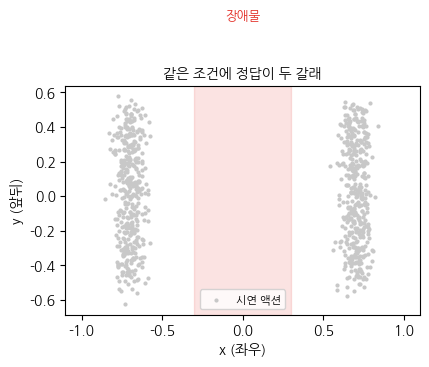

In [2]:
def make_demos(n, seed):
    r = np.random.default_rng(seed)
    c = r.uniform(-1, 1, (n, 1)).astype(np.float32)        # 장애물 세로 위치
    side = (r.integers(0, 2, n) * 2 - 1).astype(np.float32)  # 좌우 50:50
    a = np.stack([0.7 * side, c[:, 0] * 0.5], 1).astype(np.float32)
    a += r.normal(0, .05, a.shape).astype(np.float32)       # 시연자 손떨림
    return torch.from_numpy(c), torch.from_numpy(a)

C, A = make_demos(8192, 0)
VC, VA = make_demos(2048, 7)
print("조건", tuple(C.shape), "-> 액션", tuple(A.shape))

plt.figure(figsize=(4.4, 4))
plt.scatter(A[:800, 0], A[:800, 1], s=4, color=GREY, label="시연 액션")
plt.axvspan(-.3, .3, color=RED, alpha=.13)
plt.text(0, 1.02, "장애물", ha="center", color=RED, fontsize=9)
plt.xlabel("x (좌우)"); plt.ylabel("y (앞뒤)")
plt.title("같은 조건에 정답이 두 갈래", fontsize=10)
plt.legend(fontsize=8); plt.xlim(-1.1, 1.1); plt.tight_layout(); plt.show()

## 2. 회귀는 한복판으로 간다

5장의 논리를 그대로 적용하면 결과를 예측할 수 있다. 회귀 손실은 조건이 주어졌을 때의 **중앙값 하나**를 내놓는다. 왼쪽 −0.7과 오른쪽 +0.7의 가운데는 0이고, 그 자리에 장애물이 있다.

예측이 아니라 측정으로 확인한다.

In [3]:
class Regressor(nn.Module):
    def __init__(s, h=128):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(1, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, 2))
    def forward(s, c): return s.f(c)

def train_reg(steps=1200, lr=3e-3, bs=256):
    torch.manual_seed(0)
    m = Regressor(); opt = torch.optim.AdamW(m.parameters(), lr=lr)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(C), (bs,), generator=g)
        loss = F.mse_loss(m(C[idx]), A[idx])
        opt.zero_grad(); loss.backward(); opt.step()
    return m

t0 = time.time(); reg = train_reg()
with torch.no_grad(): pred_reg = reg(VC)
print(f"회귀 학습 {time.time()-t0:.0f}s")
print("예측 x 의 평균 %.3f,  표준편차 %.3f" % (pred_reg[:,0].mean(), pred_reg[:,0].std()))
print("장애물 구역(|x|<0.3)에 떨어진 비율 %.0f%%" % (100*(pred_reg[:,0].abs()<.3).float().mean()))

회귀 학습 1s
예측 x 의 평균 -0.011,  표준편차 0.023
장애물 구역(|x|<0.3)에 떨어진 비율 100%


## 3. 플로 매칭

필요한 것은 "정답 하나"가 아니라 **정답의 분포에서 표본을 뽑는 것**이다. 왼쪽과 오른쪽 중 하나를 고르되 가운데는 고르지 않아야 한다.

플로 매칭의 착상은 단순하다. 잡음에서 데이터로 흘러가는 **속도장**을 배우는 것이다.

학습할 때는 잡음 `x0`와 실제 액션 `x1`을 직선으로 잇고, 그 위의 한 점 `xt`에서 어느 방향으로 가야 하는지를 맞힌다. 정답 속도는 `x1 - x0`이다.

    xt = (1-t)·x0 + t·x1        t 는 0에서 1 사이 난수
    목표 속도 v = x1 - x0
    손실 = || f(xt, t, 조건) - v ||²

추론할 때는 잡음에서 출발해 속도장을 따라 조금씩 흘려보낸다. 오일러 적분 몇 스텝이면 된다.

핵심은 여기다. **출발점 `x0`가 난수이므로 도착점도 매번 달라진다.** 왼쪽 근처에서 출발하면 왼쪽으로, 오른쪽 근처에서 출발하면 오른쪽으로 흘러간다. 회귀와 달리 하나의 답으로 뭉개지지 않는다.

In [4]:
class VelocityField(nn.Module):
    # f(x, t, c) -> 속도.  t 는 사인·코사인으로 펼쳐 넣는다.
    def __init__(s, cond_dim=1, x_dim=2, h=128, t_dim=8):
        super().__init__()
        s.t_dim = t_dim
        s.f = nn.Sequential(nn.Linear(cond_dim + x_dim + t_dim, h), nn.GELU(),
                            nn.Linear(h, h), nn.GELU(), nn.Linear(h, x_dim))
    def forward(s, c, x, t):
        k = torch.arange(s.t_dim // 2, dtype=t.dtype)
        te = torch.cat([torch.sin(t * math.pi * 2**k), torch.cos(t * math.pi * 2**k)], -1)
        return s.f(torch.cat([c, x, te], -1))

def train_flow(steps=2500, lr=3e-3, bs=256):
    torch.manual_seed(0)
    m = VelocityField(); opt = torch.optim.AdamW(m.parameters(), lr=lr)
    g = torch.Generator().manual_seed(1)
    for i in range(steps):
        idx = torch.randint(0, len(C), (bs,), generator=g)
        x1 = A[idx]
        x0 = torch.randn_like(x1)                       # 잡음에서 출발
        t  = torch.rand(len(idx), 1)                    # 경로 위의 임의 시점
        xt = (1 - t) * x0 + t * x1                      # 직선 보간
        loss = F.mse_loss(m(C[idx], xt, t), x1 - x0)    # 목표 속도
        opt.zero_grad(); loss.backward(); opt.step()
    return m

@torch.no_grad()
def sample_flow(m, c, n_steps=10, keep_path=False, x_dim=2):
    x = torch.randn(len(c), x_dim)
    path = [x.clone()]
    for i in range(n_steps):
        t = torch.full((len(c), 1), i / n_steps)
        x = x + m(c, x, t) / n_steps                    # 오일러 한 스텝
        if keep_path: path.append(x.clone())
    return (x, path) if keep_path else x

t0 = time.time(); flow = train_flow()
pred_flow, path = sample_flow(flow, VC, 10, keep_path=True)
print(f"플로 매칭 학습 {time.time()-t0:.0f}s")
print("왼쪽을 고른 비율 %.0f%%" % (100*(pred_flow[:,0] < 0).float().mean()))
print("장애물 구역(|x|<0.3)에 떨어진 비율 %.0f%%" % (100*(pred_flow[:,0].abs()<.3).float().mean()))

플로 매칭 학습 1s
왼쪽을 고른 비율 50%
장애물 구역(|x|<0.3)에 떨어진 비율 4%


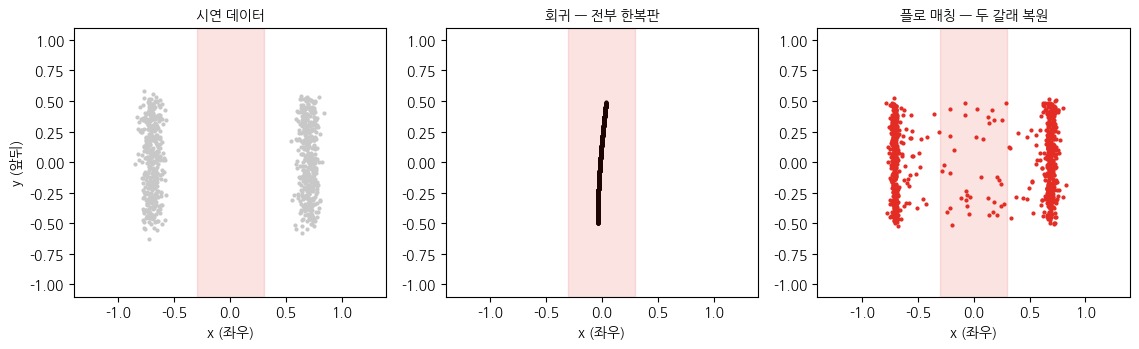

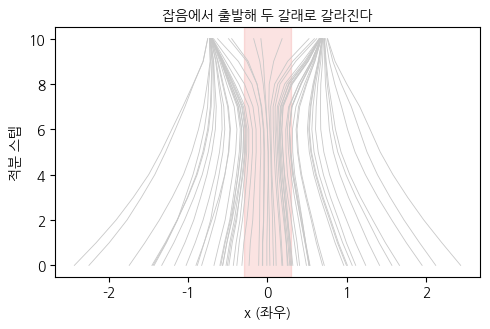

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.6))
ax[0].scatter(A[:800,0], A[:800,1], s=4, color=GREY)
ax[0].set_title("시연 데이터", fontsize=10)
ax[1].scatter(pred_reg[:800,0], pred_reg[:800,1], s=4, color="k")
ax[1].set_title("회귀 — 전부 한복판", fontsize=10)
ax[2].scatter(pred_flow[:800,0], pred_flow[:800,1], s=4, color=RED)
ax[2].set_title("플로 매칭 — 두 갈래 복원", fontsize=10)
for a in ax:
    a.axvspan(-.3, .3, color=RED, alpha=.13)
    a.set_xlim(-1.4, 1.4); a.set_ylim(-1.1, 1.1); a.set_xlabel("x (좌우)")
ax[0].set_ylabel("y (앞뒤)")
plt.tight_layout(); plt.show()

P = torch.stack(path)                      # (스텝+1, 샘플, 2)
plt.figure(figsize=(5, 3.4))
for j in range(60):
    plt.plot(P[:, j, 0], np.arange(P.shape[0]), color=GREY, lw=.6)
plt.axvspan(-.3, .3, color=RED, alpha=.13)
plt.xlabel("x (좌우)"); plt.ylabel("적분 스텝")
plt.title("잡음에서 출발해 두 갈래로 갈라진다", fontsize=10)
plt.tight_layout(); plt.show()

## 4. 스텝 수와 지연의 거래

플로 매칭은 공짜가 아니다. 샘플 하나를 뽑는 데 신경망을 **여러 번** 통과해야 한다. 회귀는 한 번이면 끝난다. 이것이 π0 같은 모델을 배포할 때 지연 예산에서 가장 먼저 손대는 손잡이다.

몇 스텝이 필요한지 재 본다.

   스텝      장애물 구역       모드까지 거리       샘플당 지연
----------------------------------------------
    1      99.3%         0.631        2.4us
    2      56.2%         0.421        2.4us
    4      12.1%         0.139        4.4us
    8       5.0%         0.089        4.9us
   16       2.7%         0.085        6.6us
   32       1.7%         0.086       13.5us
----------------------------------------------


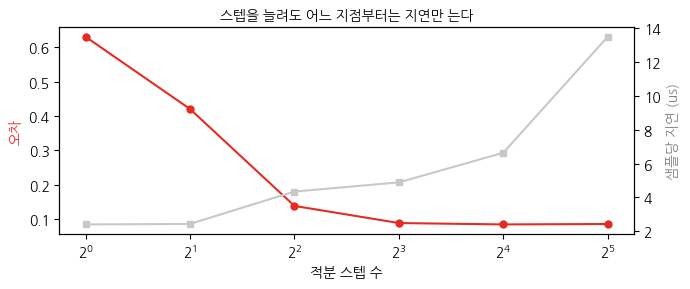

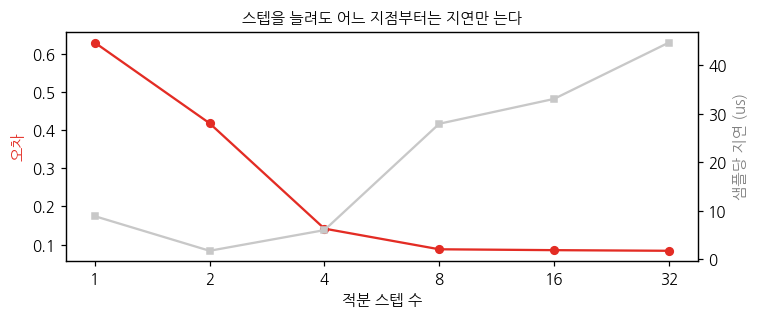

In [9]:
print(f"{'스텝':>5}{'장애물 구역':>12}{'모드까지 거리':>14}{'샘플당 지연':>13}")
print("-" * 46)
rows = []
for n in [1, 2, 4, 8, 16, 32]:
    t0 = time.time(); p = sample_flow(flow, VC, n); dt = (time.time()-t0)/len(VC)*1e6
    d = torch.minimum((p - torch.stack([ 0.7*torch.ones(len(p)), VA[:,1]], 1)).norm(dim=1),
                      (p - torch.stack([-0.7*torch.ones(len(p)), VA[:,1]], 1)).norm(dim=1))
    hit = (p[:,0].abs() < .3).float().mean().item()
    rows.append((n, hit, d.mean().item(), dt))
    print(f"{n:5d}{hit:11.1%}{d.mean():14.3f}{dt:11.1f}us")
print("-" * 46)

fig, ax1 = plt.subplots(figsize=(7, 3))
ns = [r[0] for r in rows]
ax1.plot(ns, [r[2] for r in rows], color=RED, marker="o", ms=5, label="모드까지 거리")
ax1.set_xscale("log", base=2); ax1.set_xlabel("적분 스텝 수"); ax1.set_ylabel("오차", color=RED)
ax2 = ax1.twinx()
ax2.plot(ns, [r[3] for r in rows], color=GREY, marker="s", ms=4, label="지연")
ax2.set_ylabel("샘플당 지연 (us)", color="gray")
ax1.set_title("스텝을 늘려도 어느 지점부터는 지연만 는다", fontsize=10)
plt.tight_layout(); plt.show()

## 5. 반례 — 정답이 하나면 회귀가 낫다

여기까지만 보면 플로 매칭이 우월해 보인다. 그렇지 않다.

5장에서 쓴 과제를 가져온다. 블록 두 개의 좌표와 목표 색을 주면 액션이 **하나로 정해지는** 과제다. 다봉성이 없다. 같은 학습 예산과 같은 크기로 두 방식을 비교한다.

In [10]:
AD = 7
AXES = ["dx", "dy", "dz", "roll", "pitch", "yaw", "gripper"]

def make_state_data(n, seed):
    r = np.random.default_rng(seed)
    p = r.uniform(-.8, .8, (n, 2, 2)).astype(np.float32)
    t = r.integers(0, 2, n)
    x = np.concatenate([p.reshape(n, 4), np.eye(2, dtype=np.float32)[t]], 1)
    c = p[np.arange(n), t]; d = np.hypot(c[:, 0], c[:, 1])
    a = np.stack([c[:,0], c[:,1], -0.15-0.5*d, np.zeros(n), np.zeros(n),
                  np.arctan2(c[:,1], c[:,0])/np.pi, np.where(d < .4, 1, -1)], 1).astype(np.float32)
    return torch.from_numpy(x), torch.from_numpy(np.clip(a, -1, 1))

SX, SA = make_state_data(8192, 0); TX, TA = make_state_data(2048, 7)

class StateReg(nn.Module):
    def __init__(s, h=192):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(6, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, AD))
    def forward(s, c): return s.f(c)

def fit_state(kind, steps=4000, h=192, lr=3e-3, bs=128):
    torch.manual_seed(0)
    m = StateReg(h) if kind == "reg" else VelocityField(6, AD, h, 8)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(9); t0 = time.time()
    for i in range(steps):
        idx = torch.randint(0, len(SX), (bs,), generator=g)
        c, a = SX[idx], SA[idx]
        if kind == "reg":
            loss = F.smooth_l1_loss(m(c), a, beta=.02)
        else:
            x0 = torch.randn_like(a); t = torch.rand(len(idx), 1)
            loss = F.mse_loss(m(c, (1-t)*x0 + t*a, t), a - x0)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    return m, time.time() - t0

mr, t_r = fit_state("reg"); mf, t_f = fit_state("flow")
with torch.no_grad(): p_r = mr(TX)
p_f = sample_flow(mf, TX, 10, x_dim=AD)
e_r, e_f = (p_r - TA).abs().mean(0), (p_f - TA).abs().mean(0)

print(f"학습 시간   회귀 {t_r:.0f}s   플로 매칭 {t_f:.0f}s")
print(f"\n{'축':<10}{'회귀':>10}{'플로 매칭':>13}")
print("-" * 34)
for i, n in enumerate(AXES):
    print(f"{n:<10}{e_r[i]:10.4f}{e_f[i]:13.4f}")
print("-" * 34)
print(f"{'전체':<10}{e_r.mean():10.4f}{e_f.mean():13.4f}")

학습 시간   회귀 3s   플로 매칭 3s

축                 회귀        플로 매칭
----------------------------------
dx            0.0028       0.0114
dy            0.0026       0.0105
dz            0.0037       0.0142
roll          0.0008       0.0057
pitch         0.0008       0.0064
yaw           0.0538       0.0818
gripper       0.2362       0.2527
----------------------------------
전체            0.0430       0.0547


### 다음 장으로

4장부터 6장까지 하나의 관측에서 하나의 액션을 뽑는 이야기를 했다. 실제 조작은 시간 위에서 벌어진다. 지금 프레임만 보고는 컵을 드는 중인지 놓는 중인지 알 수 없고, 방금 미끄러졌다는 것도 알 수 없다. 프레임 몇 장을 줄 것인지, 액션을 몇 스텝씩 묶을 것인지, 분 단위 과제에서 무엇을 기억할 것인지가 7장의 주제다.